# Đánh giá các Giải thuật Machine Learning trong Hệ gợi ý (Movie RecSys)

Jupyter Notebook này thực hiện nghiên cứu, thực nghiệm và đánh giá chi tiết các thuật toán Học máy truyền thống (Traditional Machine Learning) áp dụng cho hệ thống gợi ý phim trên tập dữ liệu **MovieLens Small** (`ml-latest-small`).

Nội dung nghiên cứu dựa trên các hướng dẫn lý thuyết tại tệp [evaluation/machine_learning/README.md](file:///d:/Projects/movie-recsys/evaluation/machine_learning/README.md) và phân tích đặc điểm dữ liệu tại [evaluation/eda/eda_analysis.ipynb](file:///d:/Projects/movie-recsys/evaluation/eda/eda_analysis.ipynb).

---

### Mục tiêu nghiên cứu:
1. **Tiền xử lý và Thiết lập Pipeline**: Chia tập dữ liệu Train/Test và xây dựng các hàm đo lường chất lượng:
   * **Chỉ số sai số (Regression Metrics)**: RMSE, MAE.
   * **Chỉ số xếp hạng (Ranking Metrics)**: Precision@K, Recall@K, NDCG@K.
2. **Lọc cộng tác dựa trên lân cận (Memory-Based Collaborative Filtering)**:
   * User-based Collaborative Filtering (Cosine vs. Pearson similarity).
   * Item-based Collaborative Filtering (Cosine vs. Pearson similarity).
3. **Phân rã ma trận (Model-Based Matrix Factorization - MF)**:
   * Singular Value Decomposition (SVD).
   * SVD++ (incorporate implicit feedback).
   * Non-Negative Matrix Factorization (NMF).
4. **Lọc dựa trên nội dung (Content-Based Filtering)**:
   * Sử dụng đặc trưng thể loại phim (Genres) được biểu diễn bằng vector TF-IDF để đề xuất dựa trên sở thích người dùng.
5. **Factorization Machines (FM)**:
   * Xây dựng lớp mô hình FM từ đầu bằng NumPy, tối ưu bằng SGD, tích hợp thêm thông tin phụ (Movie Genres) để vượt qua giới hạn của MF truyền thống.
6. **Đánh giá và so sánh thực nghiệm**:
   * Tổng hợp hiệu năng của các mô hình thông qua bảng số liệu và biểu đồ trực quan.
   * Thảo luận về các Use Cases thực tế, vấn đề Cold Start và Scalability.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader, KNNBasic, KNNWithMeans, SVD, SVDpp, NMF, accuracy
from collections import defaultdict
import numba

# Thêm đường dẫn cha để import recsys_utils
sys.path.append(os.path.abspath('..'))
import recsys_utils

# Configure visualization styles
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Thư viện được tải thành công!")

Thư viện được tải thành công!


## Phần 1: Tải và Khám phá Dữ liệu

Dữ liệu được tải từ thư mục `../../data/ml-latest-small/` bao gồm:
* `ratings.csv`: Chứa ratings từ người dùng (userId, movieId, rating, timestamp).
* `movies.csv`: Chứa thông tin phim (movieId, title, genres).


In [2]:
# Path to the data directory (relative to the notebook directory)
data_dir = os.path.join("..", "..", "data", "ml-latest-small")

# Read ratings and movies files
ratings = pd.read_csv(os.path.join(data_dir, "ratings.csv"))
movies = pd.read_csv(os.path.join(data_dir, "movies.csv"))

print(f"Tổng số tương tác (ratings): {len(ratings):,}")
print(f"Số lượng người dùng duy nhất (userId): {ratings['userId'].nunique():,}")
print(f"Số lượng bộ phim duy nhất (movieId): {ratings['movieId'].nunique():,}")
print(f"Mật độ ma trận tương tác (Sparsity): {100 * (1 - len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique())):.2f}%")

display(ratings.head(3))
display(movies.head(3))

Tổng số tương tác (ratings): 100,836
Số lượng người dùng duy nhất (userId): 610
Số lượng bộ phim duy nhất (movieId): 9,724
Mật độ ma trận tương tác (Sparsity): 98.30%


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


## Phần 2: Định nghĩa Evaluation Metrics (Các Chỉ số Đánh giá)

Để đánh giá một hệ gợi ý một cách toàn diện, chúng ta cần dùng cả chỉ số sai số dự đoán điểm số và chỉ số xếp hạng danh sách:

### 2.1 Chỉ số sai số (Regression Metrics):
Thích hợp cho bài toán dự đoán ratings điểm số (Explicit Feedback):
* **Root Mean Squared Error (RMSE):** Phạt nặng hơn các sai lệch lớn.
  $$RMSE = \sqrt{\frac{1}{|T|} \sum_{(u,i) \in T} (r_{u,i} - \hat{r}_{u,i})^2}$$
* **Mean Absolute Error (MAE):** Trị tuyệt đối sai số trung bình.
  $$MAE = \frac{1}{|T|} \sum_{(u,i) \in T} |r_{u,i} - \hat{r}_{u,i}|$$

### 2.2 Chỉ số xếp hạng danh sách (Ranking Metrics):
Thích hợp cho bài toán Top-K recommendations, đo lường sự hài lòng của người dùng khi nhận được một danh sách gợi ý $K$ sản phẩm:
* **Precision@K:** Tỷ lệ phim được gợi ý thực sự có liên quan (ví dụ điểm số thực tế $\ge 3.5$) nằm trong Top-K gợi ý.
  $$Precision@K = \frac{\text{Số phim liên quan gợi ý trúng trong Top-K}}{K}$$
* **Recall@K:** Tỷ lệ phim liên quan của người dùng tìm thấy được trong Top-K gợi ý.
  $$Recall@K = \frac{\text{Số phim liên quan gợi ý trúng trong Top-K}}{\text{Tổng số phim liên quan trong tập Test của user}}$$
* **NDCG@K (Normalized Discounted Cumulative Gain):** Đánh giá vị trí xếp hạng. Phim có liên quan nằm ở vị trí càng cao thì điểm NDCG càng cao.
  $$DCG@K = \sum_{i=1}^K \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$
  $$NDCG@K = \frac{DCG@K}{IDCG@K}$$
  *(Trong đó $rel_i$ là điểm đánh giá thực tế của phim ở vị trí gợi ý thứ $i$. Nếu điểm đánh giá $< 3.5$ (không liên quan) thì $rel_i = 0$. $IDCG@K$ là giá trị DCG lý tưởng nhất khi danh sách được sắp xếp tối ưu theo mức liên quan).*


In [3]:
# Import các hàm đo lường, chia dữ liệu và metrics nâng cao từ recsys_utils
from recsys_utils import (
    split_data_explicit,
    split_data_implicit_leave_one_out,
    evaluate_explicit,
    evaluate_implicit_loo,
    calculate_beyond_accuracy_metrics
)

print("Import các hàm tiện ích từ recsys_utils thành công!")

Import các hàm tiện ích từ recsys_utils thành công!


## Phần 3: Lọc Cộng Tác dựa trên Lân Cận (Memory-Based Collaborative Filtering)

Nhóm lọc cộng tác dựa trên lân cận tính toán độ tương đồng giữa User-User hoặc Item-Item.
Ta sẽ đánh giá các thuật toán KNN với hai phương pháp tiếp cận chính:
1.  **User-based Collaborative Filtering**:
    *   **Mục tiêu**: Dự đoán đánh giá của người dùng $u$ cho phim $i$ bằng cách tìm nhóm các người dùng có sở thích tương đồng (lân cận) với $u$.
    *   **Tại sao cần**: Thích hợp khi hệ thống muốn tạo sự đa dạng, gợi ý các bộ phim thuộc thể loại mới mà người dùng chưa từng xem nhưng được nhóm lân cận ưa thích.
    *   **Ứng dụng**: Phổ biến trong mạng xã hội hoặc hệ thống gợi ý tin tức nơi mối quan hệ xã hội giữa những người dùng tương đồng rất bền chặt.
2.  **Item-based Collaborative Filtering**:
    *   **Mục tiêu**: Dự đoán đánh giá của người dùng $u$ cho phim $i$ bằng cách dựa trên sự tương đồng giữa phim $i$ và các phim khác mà $u$ từng đánh giá cao trong quá khứ.
    *   **Tại sao cần**: Do số lượng sản phẩm thường ổn định hơn số lượng người dùng (ít biến động sở thích hơn), ma trận tương đồng Item-Item có thể tính toán trước (offline) hiệu quả, cải thiện tốc độ và khả năng mở rộng.
    *   **Ứng dụng**: Hiển thị danh mục "Các phim tương tự" trên trang thông tin chi tiết phim (Netflix, IMDb).

Độ tương đồng giữa hai thực thể được đo lường bằng các công thức:
* **User-based CF (Cosine vs. Pearson similarity)**:
  $$sim(u, v) = \frac{\sum_{i} (r_{u,i} - \bar{r}_u)(r_{v,i} - \bar{r}_v)}{\sqrt{\sum (r_{u,i} - \bar{r}_u)^2} \sqrt{\sum (r_{v,i} - \bar{r}_v)^2}}$$
* **Item-based CF (Cosine vs. Pearson similarity)**:
  $$sim(i, j) = \frac{\mathbf{d}_i \cdot \mathbf{d}_j}{\|\mathbf{d}_i\| \|\mathbf{d}_j\|}$$


In [4]:
# Chia dữ liệu Train/Test explicit nhất quán từ recsys_utils
train_df, test_df = split_data_explicit(ratings, test_size=0.2, random_state=42)

# Thiết lập Reader và Dataset của Surprise
reader = Reader(rating_scale=(0.5, 5.0))
# Chuyển đổi DataFrame sang định dạng Trainset và Testset của Surprise để huấn luyện đồng nhất
trainset = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader).build_full_trainset()
testset = list(zip(test_df['userId'], test_df['movieId'], test_df['rating']))

# Khởi tạo bảng lưu trữ kết quả so sánh
explicit_results = []
implicit_results = []

# Cấu hình các tham số KNN để thử nghiệm
knn_configs = [
    {"name": "User-Based KNN (Cosine)", "user_based": True, "similarity": "cosine"},
    {"name": "User-Based KNN (Pearson)", "user_based": True, "similarity": "pearson"},
    {"name": "Item-Based KNN (Cosine)", "user_based": False, "similarity": "cosine"},
    {"name": "Item-Based KNN (Pearson)", "user_based": False, "similarity": "pearson"}
]

for config in knn_configs:
    print(f"Đang huấn luyện {config['name']}...")
    
    sim_options = {
        'name': config['similarity'],
        'user_based': config['user_based']
    }
    
    model = KNNWithMeans(sim_options=sim_options, verbose=False)
    model.fit(trainset)
    
    predictions = model.test(testset)
    
    # Đo lường bằng RMSE và MAE trên explicit pipeline
    rmse, mae = evaluate_explicit([(true_r, est) for _, _, true_r, est, _ in predictions])
    
    explicit_results.append({
        "Model": config['name'],
        "RMSE": rmse,
        "MAE": mae
    })
    print(f"-> RMSE: {rmse:.4f} | MAE: {mae:.4f}\n")

pd.DataFrame(explicit_results)

Đang huấn luyện User-Based KNN (Cosine)...
-> RMSE: 0.9093 | MAE: 0.6939

Đang huấn luyện User-Based KNN (Pearson)...
-> RMSE: 0.9042 | MAE: 0.6863

Đang huấn luyện Item-Based KNN (Cosine)...
-> RMSE: 0.9141 | MAE: 0.6961

Đang huấn luyện Item-Based KNN (Pearson)...
-> RMSE: 0.9109 | MAE: 0.6917



,Model,RMSE,MAE
0,User-Based KNN (Cosine),0.909306,0.693897
1,User-Based KNN (Pearson),0.904168,0.686255
2,Item-Based KNN (Cosine),0.914133,0.696117
3,Item-Based KNN (Pearson),0.910921,0.691705


## Phần 4: Phân rã Ma trận (Model-Based Matrix Factorization)

Phương pháp này phân rã ma trận tương tác $R \in \mathbb{R}^{M \times N}$ thành tích hai ma trận hạng thấp biểu diễn các ẩn thuộc tính (latent factors) của Người dùng $P \in \mathbb{R}^{M \times K}$ và Phim $Q \in \mathbb{R}^{N \times K}$:
$$\hat{r}_{u,i} = \mu + b_u + b_i + q_i^T p_u$$
Hàm loss tối ưu:
$$\min_{P, Q, b} \sum_{(u,i) \in K} (r_{u,i} - \mu - b_u - b_i - q_i^T p_u)^2 + \lambda \left( \|p_u\|_2^2 + \|q_i\|_2^2 + b_u^2 + b_i^2 \right)$$

Chúng ta sẽ thực nghiệm 3 thuật toán Matrix Factorization:
1.  **SVD (Singular Value Decomposition)**:
    *   **Mục tiêu**: Học các vector biểu diễn ẩn (latent vectors) cho người dùng và phim để tối ưu hóa sai số bình phương trung bình (MSE) giữa ratings thực tế và dự đoán qua thuật toán hạ độ dốc ngẫu nhiên (SGD).
    *   **Tại sao cần**: Giúp giải quyết cực kỳ tốt bài toán ma trận tương tác siêu thưa thớt bằng cách giảm chiều dữ liệu xuống không gian ẩn $K$ chiều cô đọng.
    *   **Ứng dụng**: Thuật toán cốt lõi làm nên chiến thắng trong cuộc thi Netflix Prize trị giá 1 triệu USD.
2.  **SVD++**:
    *   **Mục tiêu**: Mở rộng SVD bằng cách tích hợp thêm hành vi tương tác ngầm định (implicit feedback), cụ thể là tập hợp các phim mà người dùng đã từng đánh giá bất kể số điểm cụ thể.
    *   **Tại sao cần**: Lịch sử xem phim/đánh giá (dù thích hay ghét) chứa đựng tín hiệu sở thích rất mạnh mẽ, giúp nâng cao chất lượng nhúng của người dùng đặc biệt là khi họ đánh giá rất ít phim.
    *   **Ứng dụng**: Phù hợp cho các nền tảng phát trực tuyến có lượng dữ liệu lịch sử click/xem phim lớn nhưng số lượng rating chấm điểm trực tiếp nhỏ.
3.  **NMF (Non-negative Matrix Factorization)**:
    *   **Mục tiêu**: Thực hiện phân rã ma trận với ràng buộc phi âm nghiêm ngặt lên tất cả các thành phần ẩn ($P \ge 0, Q \ge 0$).
    *   **Tại sao cần**: Tạo điều kiện giải thích mô hình vượt trội. Vì không có các giá trị âm triệt tiêu lẫn nhau, các chiều ẩn đại diện rõ ràng cho mức độ pha trộn các thể loại hoặc phong cách phim (ví dụ: phim X có $40\%$ hành động, $60\%$ trinh thám).
    *   **Ứng dụng**: Thích hợp khi hệ gợi ý cần cung cấp lý do gợi ý mang tính định lượng để thuyết phục người dùng.


In [5]:
mf_models = [
    {"name": "SVD", "class": SVD(random_state=42)},
    {"name": "SVD++", "class": SVDpp(random_state=42)},
    {"name": "NMF", "class": NMF(random_state=42)}
]

for config in mf_models:
    print(f"Đang huấn luyện {config['name']}...")
    model = config['class']
    model.fit(trainset)
    
    predictions = model.test(testset)
    
    # Đo lường bằng RMSE và MAE trên explicit pipeline
    rmse, mae = evaluate_explicit([(true_r, est) for _, _, true_r, est, _ in predictions])
    
    explicit_results.append({
        "Model": config['name'],
        "RMSE": rmse,
        "MAE": mae
    })
    print(f"-> RMSE: {rmse:.4f} | MAE: {mae:.4f}\n")

pd.DataFrame(explicit_results)

Đang huấn luyện SVD...
-> RMSE: 0.8831 | MAE: 0.6749

Đang huấn luyện SVD++...
-> RMSE: 0.8676 | MAE: 0.6630

Đang huấn luyện NMF...
-> RMSE: 0.9262 | MAE: 0.7089



,Model,RMSE,MAE
0,User-Based KNN (Cosine),0.909306,0.693897
1,User-Based KNN (Pearson),0.904168,0.686255
2,Item-Based KNN (Cosine),0.914133,0.696117
3,Item-Based KNN (Pearson),0.910921,0.691705
4,SVD,0.883105,0.674875
5,SVD++,0.867633,0.663018
6,NMF,0.926250,0.708854


## Phần 5: Lọc Dựa trên Nội dung (Content-Based Filtering)

### Nguyên lý hoạt động
Lọc dựa trên nội dung đề xuất các bộ phim tương tự với những bộ phim mà người dùng đã thích trước đây dựa trên thuộc tính phim.
*   **Mục tiêu**: Dự đoán mức độ yêu thích của người dùng đối với một bộ phim bằng cách so khớp hồ sơ sở thích của người dùng (User Profile) với các thuộc tính nội dung của phim (thể loại, tác giả, đạo diễn, mô tả tóm tắt).
*   **Tại sao cần**: Đây là giải pháp hữu hiệu nhất để giải quyết triệt để **bài toán khởi đầu lạnh cho sản phẩm mới (New Item Cold Start)**. Khi một bộ phim mới được đưa lên hệ thống, nó chưa hề có lượt xem hay rating nào, các thuật toán Collaborative Filtering sẽ bó tay. Nhưng lọc nội dung chỉ cần thông tin thể loại để so khớp ngay lập tức.
*   **Ứng dụng**: Phổ biến trong gợi ý tin tức (News Recommendation) dựa trên từ khóa bài viết, gợi ý sách dựa trên tác giả và danh mục, hoặc gợi ý sản phẩm dựa trên nhãn thuộc tính.

Các bước thực hiện trong thực nghiệm này:
1. **Biểu diễn phim**: Ta dùng thể loại phim `genres` để tạo vector đặc trưng. Ta áp dụng phương pháp **TF-IDF** (Term Frequency - Inverse Document Frequency) lên genres để đánh trọng số thể loại (ví dụ thể loại hiếm sẽ mang nhiều thông tin hơn thể loại phổ biến).
2. **Xây dựng User Profile**: User Profile được biểu diễn bằng vector có chiều bằng số thể loại phim, là trung bình cộng của các vector đặc trưng phim mà người dùng đó đã thích (rating $\ge 3.5$), được nhân trọng số theo điểm rating thực tế.
3. **Gợi ý**: Dự đoán độ yêu thích của người dùng $u$ đối với phim $i$ bằng **Cosine Similarity** giữa vector User Profile của $u$ và vector đặc trưng của phim $i$.


In [6]:
# 1. Chuẩn bị đặc trưng thể loại phim
# Thay thế dấu '|' bằng khoảng trắng để TF-IDF Vectorizer xử lý
movies_genres = movies.copy()
movies_genres['genres_clean'] = movies_genres['genres'].str.replace('|', ' ', regex=False)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b') # Hỗ trợ thể loại có 1 chữ
tfidf_matrix = tfidf.fit_transform(movies_genres['genres_clean'])
movie_features = pd.DataFrame(tfidf_matrix.toarray(), index=movies_genres['movieId'])

# 2. Xây dựng User Profile trên tập Train (sử dụng train_df từ Cell 8)
user_profiles = {}
grouped = train_df.groupby('userId')

for uid, group in grouped:
    # Chỉ lấy các tương tác tích cực của người dùng (rating >= 3.5) để xây dựng sở thích
    positive_interactions = group[group['rating'] >= 3.5]
    if len(positive_interactions) == 0:
        # Nếu không có rating >= 3.5, lấy toàn bộ lịch sử
        positive_interactions = group
        
    interacted_movie_ids = positive_interactions['movieId'].values
    weights = positive_interactions['rating'].values - 2.5 # Trừ đi mức trung bình để tạo độ lệch trọng số tích cực
    
    # Lấy đặc trưng của các bộ phim tương tác
    valid_movie_ids = [mid for mid in interacted_movie_ids if mid in movie_features.index]
    if not valid_movie_ids:
        continue
    
    movie_feats = movie_features.loc[valid_movie_ids].values
    weights = weights[[i for i, mid in enumerate(interacted_movie_ids) if mid in movie_features.index]]
    
    # Tính trung bình có trọng số của các vector đặc trưng phim
    user_profile = np.dot(weights, movie_feats) / np.sum(weights)
    user_profiles[uid] = user_profile

# 3. Dự đoán trên tập Test (sử dụng test_df từ Cell 8)
content_predictions = []
for idx, row in test_df.iterrows():
    uid = int(row['userId'])
    mid = int(row['movieId'])
    true_r = row['rating']
    
    # Dự đoán bằng độ tương đồng Cosine
    if uid in user_profiles and mid in movie_features.index:
        u_vector = user_profiles[uid].reshape(1, -1)
        m_vector = movie_features.loc[mid].values.reshape(1, -1)
        sim = cosine_similarity(u_vector, m_vector)[0][0]
        # Quy đổi sim (0 đến 1) sang thang điểm rating (0.5 đến 5.0)
        est = 0.5 + sim * 4.5
    else:
        # Fallback về điểm rating trung bình toàn hệ thống của tập train
        est = train_df['rating'].mean()
        
    content_predictions.append((true_r, est))

# 4. Tính toán Metrics cho Content-Based sử dụng explicit evaluation helper
rmse_cb, mae_cb = evaluate_explicit(content_predictions)

explicit_results.append({
    "Model": "Content-Based Filtering (TF-IDF)",
    "RMSE": rmse_cb,
    "MAE": mae_cb
})

print("Đánh giá mô hình Content-Based thành công!")
print(f"RMSE: {rmse_cb:.4f} | MAE: {mae_cb:.4f}")

Đánh giá mô hình Content-Based thành công!
RMSE: 1.5235 | MAE: 1.2540


## Phần 6: Tự xây dựng Factorization Machines (FM) bằng NumPy

### 6.1 Cơ chế hoạt động của Factorization Machines
Mô hình Factorization Machine (FM) cải tiến Matrix Factorization bằng cách chấp nhận mọi vector đặc trưng đầu vào $x \in \mathbb{R}^d$ chứa các thông tin phụ (side information).
*   **Mục tiêu**: Dự đoán giá trị tương tác bằng cách kết hợp giữa các trọng số tuyến tính bậc 1 (linear effects) và các tương tác chéo bậc 2 (pairwise feature interactions) giữa tất cả các thuộc tính đầu vào.
*   **Tại sao cần**: FM khắc phục nhược điểm lớn nhất của SVD (không thể sử dụng các thông tin phụ như thể loại phim, độ tuổi, thời gian nếu không huấn luyện lại) và khắc phục nhược điểm của hồi quy tuyến tính (không tự động học được tương tác chéo giữa các đặc trưng thưa thớt). Đồng thời, thuật toán rút gọn của Steffen Rendle đưa độ phức tạp về dạng tuyến tính, giúp mô hình chạy siêu nhanh.
*   **Ứng dụng**: Phù hợp cho các bài toán dự đoán CTR (Click-Through Rate) hiển thị quảng cáo, gợi ý sản phẩm đi kèm thông tin ngữ cảnh thời gian/vị trí.

Công thức ước lượng của FM bậc 2:
$$\hat{y}(x) = w_0 + \sum_{j=1}^d w_j x_j + \sum_{j=1}^d \sum_{l=j+1}^d \langle v_j, v_l \rangle x_j x_l$$

Kỹ thuật biến đổi toán học của Steffen Rendle giúp giảm độ phức tạp tính toán của số hạng tương tác từ $\mathcal{O}(d^2)$ xuống **tuyến tính** $\mathcal{O}(k \cdot d)$:
$$\sum_{j=1}^d \sum_{l=j+1}^d \langle v_j, v_l \rangle x_j x_l = \frac{1}{2} \sum_{f=1}^k \left( \left( \sum_{j=1}^d v_{j,f} x_j \right)^2 - \sum_{j=1}^d v_{j,f}^2 x_j^2 \right)$$

### 6.2 Cài đặt FM trên User ID + Item ID + Movie Genres (Thông tin phụ)
Chúng ta sẽ tạo đặc trưng đầu vào $x$ gồm:
*   Mã người dùng (User ID) dạng One-Hot.
*   Mã phim (Item ID) dạng One-Hot.
*   Thể loại phim (Genres) dạng Multi-Hot (đây là thông tin phụ mà SVD truyền thống không dùng được trực tiếp).


In [7]:
import numba

@numba.njit
def fm_sgd_update(indptr, indices, data, y, w0, w, V, lr, reg, k_latent, epochs):
    n_samples = len(y)
    for epoch in range(epochs):
        loss_sum = 0.0
        for idx in range(n_samples):
            start = indptr[idx]
            end = indptr[idx+1]
            
            idx_cols = indices[start:end]
            val_cols = data[start:end]
            y_true = y[idx]
            
            # 1. Tính toán giá trị dự đoán y_pred
            # Thành phần tuyến tính w0 + w^T * x
            linear_sum = w0
            for i in range(len(idx_cols)):
                j = idx_cols[i]
                val = val_cols[i]
                linear_sum += w[j] * val
                
            # Thành phần tương tác bậc hai
            interaction_sum = 0.0
            for f in range(k_latent):
                sum_v_x = 0.0
                sum_v2_x2 = 0.0
                for i in range(len(idx_cols)):
                    j = idx_cols[i]
                    val = val_cols[i]
                    v_jf = V[j, f]
                    sum_v_x += v_jf * val
                    sum_v2_x2 += (v_jf ** 2) * (val ** 2)
                interaction_sum += (sum_v_x ** 2) - sum_v2_x2
                
            y_pred = linear_sum + 0.5 * interaction_sum
            
            # Ràng buộc dự đoán
            if y_pred < 0.5:
                y_pred = 0.5
            elif y_pred > 5.0:
                y_pred = 5.0
                
            err = y_pred - y_true
            loss_sum += err ** 2
            
            # 2. Cập nhật các tham số qua Gradient Descent
            w0 -= lr * err
            
            # Cập nhật linear weights w_j
            for i in range(len(idx_cols)):
                j = idx_cols[i]
                val = val_cols[i]
                w[j] -= lr * (err * val + reg * w[j])
                
            # Cập nhật latent factors V_{j,f}
            for f in range(k_latent):
                sum_v_x = 0.0
                for i in range(len(idx_cols)):
                    j = idx_cols[i]
                    val = val_cols[i]
                    sum_v_x += V[j, f] * val
                    
                for i in range(len(idx_cols)):
                    j = idx_cols[i]
                    val = val_cols[i]
                    grad_v = err * val * (sum_v_x - V[j, f] * val)
                    V[j, f] -= lr * (grad_v + reg * V[j, f])
                    
        rmse = np.sqrt(loss_sum / n_samples)
        # Giảm tỷ lệ học (Learning rate decay)
        lr *= 0.9
        
    return w0, w, V

class FactorizationMachine:
    def __init__(self, k_latent=8, lr=0.01, reg=0.02, epochs=10, random_state=42):
        self.k = k_latent # Số latent factors
        self.lr = lr       # Tỷ lệ học (Learning rate)
        self.reg = reg     # L2 regularization
        self.epochs = epochs
        self.rng = np.random.default_rng(random_state)
        
    def _prepare_data(self, df, genres_df, is_train=True):
        if is_train:
            self.user_to_idx = {uid: i for i, uid in enumerate(df['userId'].unique())}
            self.movie_to_idx = {mid: i for i, mid in enumerate(df['movieId'].unique())}
            
            # Trích xuất tất cả thể loại phim
            all_genres = set()
            for g in genres_df['genres'].str.split('|'):
                all_genres.update(g)
            self.genre_to_idx = {genre: i for i, genre in enumerate(sorted(list(all_genres)))}
            
            self.num_users = len(self.user_to_idx)
            self.num_movies = len(self.movie_to_idx)
            self.num_genres = len(self.genre_to_idx)
            self.d = self.num_users + self.num_movies + self.num_genres # Số chiều đặc trưng
            
        n_samples = len(df)
        X_indices = []
        X_values = []
        y = df['rating'].values
        
        # Tạo mapping phim sang thể loại
        movie_genres_map = {}
        for _, row in genres_df.iterrows():
            m_id = row['movieId']
            g_list = row['genres'].split('|')
            movie_genres_map[m_id] = [self.genre_to_idx[g] for g in g_list if g in self.genre_to_idx]
            
        for idx, row in df.iterrows():
            uid = row['userId']
            mid = row['movieId']
            
            u_idx = self.user_to_idx.get(uid, None)
            m_idx = self.movie_to_idx.get(mid, None)
            
            indices = []
            values = []
            
            # One-Hot User
            if u_idx is not None:
                indices.append(u_idx)
                values.append(1.0)
                
            # One-Hot Movie (dịch chuyển index sau vùng user)
            if m_idx is not None:
                indices.append(self.num_users + m_idx)
                values.append(1.0)
                
            # Multi-Hot Genres (dịch chuyển index sau vùng user và movie)
            if mid in movie_genres_map:
                g_indices = movie_genres_map[mid]
                if g_indices:
                    # Trọng số chuẩn hóa của genres
                    val = 1.0 / len(g_indices)
                    for g_idx in g_indices:
                        indices.append(self.num_users + self.num_movies + g_idx)
                        values.append(val)
            
            X_indices.append(indices)
            X_values.append(values)
            
        return X_indices, X_values, y
        
    def fit(self, train_df, genres_df):
        X_indices, X_values, y = self._prepare_data(train_df, genres_df, is_train=True)
        
        # Khởi tạo tham số
        self.w0 = np.mean(y) # Trọng số chệch toàn cục (global bias)
        self.w = self.rng.normal(0.0, 0.1, size=self.d) # Trọng số bậc một (linear weights)
        self.V = self.rng.normal(0.0, 0.1, size=(self.d, self.k)) # Vector tương tác bậc hai
        
        print(f"Khởi tạo FM thành công. Tổng số đặc trưng (d): {self.d:,}")
        
        # Huấn luyện mô hình bằng Stochastic Gradient Descent (SGD)
        for epoch in range(self.epochs):
            loss_sum = 0
            for idx in range(len(y)):
                indices = X_indices[idx]
                values = X_values[idx]
                y_true = y[idx]
                
                # 1. Tính toán giá trị dự đoán y_pred
                # Thành phần tuyến tính w0 + w^T * x
                linear_sum = self.w0 + sum(self.w[j] * val for j, val in zip(indices, values))
                
                # Thành phần tương tác bậc hai
                interaction_sum = 0.0
                for f in range(self.k):
                    sum_v_x = sum(self.V[j, f] * val for j, val in zip(indices, values))
                    sum_v2_x2 = sum((self.V[j, f] ** 2) * (val ** 2) for j, val in zip(indices, values))
                    interaction_sum += (sum_v_x ** 2) - sum_v2_x2
                    
                y_pred = linear_sum + 0.5 * interaction_sum
                
                # Ràng buộc kết quả dự đoán trong khoảng [0.5, 5.0]
                y_pred = max(0.5, min(5.0, y_pred))
                
                # Sai số (Error)
                err = y_pred - y_true
                loss_sum += err ** 2
                
                # 2. Cập nhật các tham số qua Gradient Descent
                self.w0 -= self.lr * err
                
                # Cập nhật linear weights w_j
                for j, val in zip(indices, values):
                    self.w[j] -= self.lr * (err * val + self.reg * self.w[j])
                    
                # Cập nhật latent factors V_{j,f}
                for f in range(self.k):
                    # Tính toán trước tổng của V_{j,f} * x_j
                    sum_v_x = sum(self.V[idx_j, f] * val_j for idx_j, val_j in zip(indices, values))
                    for j, val in zip(indices, values):
                        grad_v = err * val * (sum_v_x - self.V[j, f] * val)
                        self.V[j, f] -= self.lr * (grad_v + self.reg * self.V[j, f])
                        
            rmse = np.sqrt(loss_sum / len(y))
            # Giảm tỷ lệ học (Learning rate decay) để hội tụ tốt hơn
            self.lr *= 0.9
            if (epoch + 1) % 2 == 0 or epoch == 0:
                print(f"Epoch {epoch+1:02d}/{self.epochs:02d} | Train RMSE: {rmse:.4f}")
                
    def predict(self, test_df, genres_df):
        X_indices, X_values, y_true = self._prepare_data(test_df, genres_df, is_train=False)
        predictions = []
        
        for idx in range(len(y_true)):
            indices = X_indices[idx]
            values = X_values[idx]
            
            linear_sum = self.w0 + sum(self.w[j] * val for j, val in zip(indices, values))
            
            interaction_sum = 0.0
            for f in range(self.k):
                sum_v_x = sum(self.V[j, f] * val for j, val in zip(indices, values))
                sum_v2_x2 = sum((self.V[j, f] ** 2) * (val ** 2) for j, val in zip(indices, values))
                interaction_sum += (sum_v_x ** 2) - sum_v2_x2
                
            y_pred = linear_sum + 0.5 * interaction_sum
            y_pred = max(0.5, min(5.0, y_pred))
            
            # Lưu theo định dạng để sử dụng hàm precision_recall_ndcg_at_k
            uid = test_df.iloc[idx]['userId']
            mid = test_df.iloc[idx]['movieId']
            predictions.append((uid, mid, y_true[idx], y_pred, None))
            
        return predictions

print("Định nghĩa class FactorizationMachine thành công!")

Định nghĩa class FactorizationMachine thành công!


In [8]:
# Khởi tạo và huấn luyện mô hình FM
fm_model = FactorizationMachine(k_latent=10, lr=0.02, reg=0.03, epochs=10, random_state=42)
fm_model.fit(train_df, movies)

# Dự đoán trên tập Test
fm_predictions = fm_model.predict(test_df, movies)

# Tính toán các Metrics sử dụng explicit evaluation helper
rmse_fm, mae_fm = evaluate_explicit([(true_r, est) for _, _, true_r, est, _ in fm_predictions])

explicit_results.append({
    "Model": "Factorization Machine (NumPy)",
    "RMSE": rmse_fm,
    "MAE": mae_fm
})

print("\nĐánh giá mô hình FM thành công!")
print(f"RMSE: {rmse_fm:.4f} | MAE: {mae_fm:.4f}")

Khởi tạo FM thành công. Tổng số đặc trưng (d): 9,613
Epoch 01/10 | Train RMSE: 0.9217
Epoch 02/10 | Train RMSE: 0.8695
Epoch 04/10 | Train RMSE: 0.8355
Epoch 06/10 | Train RMSE: 0.8112
Epoch 08/10 | Train RMSE: 0.7899
Epoch 10/10 | Train RMSE: 0.7712

Đánh giá mô hình FM thành công!
RMSE: 0.8612 | MAE: 0.6561


## Phần 7: Bayesian Personalized Ranking (BPR) và Alternating Least Squares (ALS) cho Implicit Feedback

Bây giờ chúng ta sẽ mở rộng đánh giá với hai thuật toán học máy cổ điển phổ biến khác được thiết kế riêng hoặc tối ưu cho dữ liệu tương tác ngầm định (Implicit Feedback) hoặc xếp hạng danh sách:

### 7.1 Bayesian Personalized Ranking (BPR)
*   **Mục tiêu**: Tối ưu hóa trực tiếp cho bài toán xếp hạng danh sách tương đối (pairwise ranking) thay vì dự đoán sai số điểm số (pointwise MSE). Đối với mỗi user, mô hình học cách đẩy sản phẩm đã tương tác lên trên sản phẩm chưa tương tác.
*   **Tại sao cần**: Trong thực tế, hầu hết phản hồi là ngầm định (click, view) chứ không có đánh giá sao cụ thể. Nếu dùng phương pháp tối ưu MSE (như SVD truyền thống) trên dữ liệu thô, ta phải giả định các phim chưa xem mang nhãn 0, điều này không đúng vì có thể họ chưa biết phim đó. BPR giải quyết việc này bằng cách xếp hạng cặp.
*   **Ứng dụng**: Gợi ý các danh sách Top-K cho các hệ thống video, nghe nhạc (Implicit feedback).

### 7.2 Alternating Least Squares (ALS) cho Implicit Feedback
*   **Mục tiêu**: Phân rã ma trận tương tác lớn với trọng số tin cậy (Confidence score) tỷ lệ thuận với tần suất tương tác, giải luân phiên ma trận để song song hóa dễ dàng.
*   **Tại sao cần**: Thuật toán SGD truyền thống khó song song hóa trên hệ thống lớn. ALS đưa bài toán phi tuyến về dạng bình phương tối thiểu tuyến tính độc lập, cực kỳ dễ chạy phân tán trên nhiều máy (như Apache Spark).
*   **Ứng dụng**: Phân rã ma trận song song hóa phân tán quy mô lớn (chuẩn công nghiệp trong Apache Spark).


In [9]:
import random
import numba

@numba.njit
def bpr_sgd_update(user_pos_flat, user_pos_indptr, num_users, num_movies, b, P, Q, lr, reg, latent_dim, epochs):
    n_users_have_pos = len(user_pos_indptr) - 1
    for epoch in range(epochs):
        loss_sum = 0.0
        
        # Lặp qua số lượng tương tác ước tính
        n_steps = n_users_have_pos * 50
        for _ in range(n_steps):
            # Chọn user ngẫu nhiên có tương tác dương
            u_idx = random.randint(0, n_users_have_pos - 1)
            
            start = user_pos_indptr[u_idx]
            end = user_pos_indptr[u_idx+1]
            n_pos = end - start
            if n_pos == 0:
                continue
                
            # Chọn positive item ngẫu nhiên
            pos_idx = random.randint(0, n_pos - 1)
            i_idx = user_pos_flat[start + pos_idx]
            
            # Chọn negative item ngẫu nhiên j_idx
            j_idx = random.randint(0, num_movies - 1)
            # Kiểm tra xem j_idx có phải phim dương của user không
            is_pos = True
            while is_pos:
                j_idx = random.randint(0, num_movies - 1)
                is_pos = False
                for k in range(start, end):
                    if user_pos_flat[k] == j_idx:
                        is_pos = True
                        break
            
            # SGD Update
            x_u = P[u_idx]
            x_i = Q[i_idx]
            x_j = Q[j_idx]
            
            score_diff = b[i_idx] - b[j_idx]
            for f in range(latent_dim):
                score_diff += x_u[f] * (x_i[f] - x_j[f])
                
            d_loss = 1.0 / (1.0 + np.exp(score_diff))
            
            # Update bias
            b[i_idx] -= lr * (-d_loss + reg * b[i_idx])
            b[j_idx] -= lr * (d_loss + reg * b[j_idx])
            
            # Update latent vectors
            for f in range(latent_dim):
                p_uf = P[u_idx, f]
                q_if = Q[i_idx, f]
                q_jf = Q[j_idx, f]
                
                P[u_idx, f] -= lr * (-d_loss * (q_if - q_jf) + reg * p_uf)
                Q[i_idx, f] -= lr * (-d_loss * p_uf + reg * q_if)
                Q[j_idx, f] -= lr * (d_loss * p_uf + reg * q_jf)
                
    return b, P, Q

class BPRMatrixFactorization:
    def __init__(self, k_latent=10, lr=0.05, reg=0.03, epochs=5, random_state=42):
        self.k = k_latent
        self.lr = lr
        self.reg = reg
        self.epochs = epochs
        self.random_state = random_state
        
    def fit(self, train_df):
        random.seed(self.random_state)
        
        self.user_to_idx = {uid: i for i, uid in enumerate(train_df['userId'].unique())}
        self.movie_to_idx = {mid: i for i, mid in enumerate(train_df['movieId'].unique())}
        self.idx_to_movie = {i: mid for mid, i in self.movie_to_idx.items()}
        self.num_users = len(self.user_to_idx)
        self.num_movies = len(self.movie_to_idx)
        
        rng = np.random.default_rng(self.random_state)
        self.b = rng.normal(0.0, 0.1, size=self.num_movies)
        self.P = rng.normal(0.0, 0.1, size=(self.num_users, self.k))
        self.Q = rng.normal(0.0, 0.1, size=(self.num_movies, self.k))
        
        user_pos_df = train_df[train_df['rating'] >= 3.5]
        if len(user_pos_df) == 0:
            user_pos_df = train_df
            
        user_pos_dict = user_pos_df.groupby('userId')['movieId'].apply(list).to_dict()
        
        # Chuẩn bị dữ liệu phẳng cho Numba
        user_pos_flat = []
        user_pos_indptr = [0]
        
        for uid in self.user_to_idx.keys():
            items = user_pos_dict.get(uid, [])
            item_indices = [self.movie_to_idx[mid] for mid in items if mid in self.movie_to_idx]
            user_pos_flat.extend(item_indices)
            user_pos_indptr.append(len(user_pos_flat))
            
        user_pos_flat = np.array(user_pos_flat, dtype=np.int32)
        user_pos_indptr = np.array(user_pos_indptr, dtype=np.int32)
        
        print("Đang huấn luyện BPR sử dụng Numba JIT...")
        self.b, self.P, self.Q = bpr_sgd_update(
            user_pos_flat, user_pos_indptr, self.num_users, self.num_movies,
            self.b, self.P, self.Q, self.lr, self.reg, self.k, self.epochs
        )
        print("Huấn luyện BPR hoàn thành.")
        
    def predict_loo(self, test_data):
        predictions_dict = {}
        for uid, pos_item, neg_items in test_data:
            items = [pos_item] + neg_items
            u_idx = self.user_to_idx.get(uid, None)
            
            user_preds = []
            for item in items:
                m_idx = self.movie_to_idx.get(item, None)
                is_pos = (item == pos_item)
                
                if u_idx is not None and m_idx is not None:
                    score = self.b[m_idx] + np.dot(self.P[u_idx], self.Q[m_idx])
                else:
                    score = 0.0
                user_preds.append((item, score, is_pos))
            predictions_dict[uid] = user_preds
        return predictions_dict

print("Định nghĩa class BPRMatrixFactorization thành công!")

Định nghĩa class BPRMatrixFactorization thành công!


In [10]:
class ImplicitALS:
    def __init__(self, k_latent=8, alpha=15, reg=0.05, epochs=5, random_state=42):
        self.k = k_latent
        self.alpha = alpha
        self.reg = reg
        self.epochs = epochs
        self.rng = np.random.default_rng(random_state)
        
    def fit(self, train_df):
        self.user_to_idx = {uid: i for i, uid in enumerate(train_df['userId'].unique())}
        self.movie_to_idx = {mid: i for i, mid in enumerate(train_df['movieId'].unique())}
        self.num_users = len(self.user_to_idx)
        self.num_movies = len(self.movie_to_idx)
        
        # Khởi tạo ma trận ẩn cho user và movie
        self.P = self.rng.normal(0.0, 0.1, size=(self.num_users, self.k))
        self.Q = self.rng.normal(0.0, 0.1, size=(self.num_movies, self.k))
        
        # Lưu các giá trị rating dạng map để truy vấn nhanh hơn
        user_ratings_map = defaultdict(dict)
        for _, row in train_df.iterrows():
            u = row['userId']
            m = row['movieId']
            r = row['rating']
            user_ratings_map[self.user_to_idx[u]][self.movie_to_idx[m]] = r
            
        # Xây dựng trước item_ratings_map bên ngoài vòng lặp epochs để tối ưu hiệu năng
        item_ratings_map = defaultdict(dict)
        for u, ratings_dict in user_ratings_map.items():
            for m, r in ratings_dict.items():
                item_ratings_map[m][u] = r
                
        # ALS Alternating Updates
        for epoch in range(self.epochs):
            # Precompute Q^T * Q và P^T * P
            QTQ = np.dot(self.Q.T, self.Q)
            PTP = np.dot(self.P.T, self.P)
            
            # 1. Cập nhật ma trận người dùng P
            for u in range(self.num_users):
                u_ratings = user_ratings_map[u]
                if not u_ratings:
                    continue
                i_indices = list(u_ratings.keys())
                r_vals = np.array(list(u_ratings.values()))
                
                # Confidence C_ui = 1 + alpha * r_ui
                conf = 1.0 + self.alpha * r_vals
                pref = 1.0 # Preference nhị phân (có tương tác = 1)
                
                Q_u = self.Q[i_indices]
                A = QTQ + np.dot(Q_u.T, (conf - 1.0)[:, None] * Q_u) + self.reg * np.eye(self.k)
                b = np.dot(Q_u.T, conf * pref)
                
                self.P[u] = np.linalg.solve(A, b)
                
            # 2. Cập nhật ma trận bộ phim Q
            for i in range(self.num_movies):
                i_ratings = item_ratings_map[i]
                if not i_ratings:
                    continue
                u_indices = list(i_ratings.keys())
                r_vals = np.array(list(i_ratings.values()))
                
                conf = 1.0 + self.alpha * r_vals
                pref = 1.0
                
                P_i = self.P[u_indices]
                A = PTP + np.dot(P_i.T, (conf - 1.0)[:, None] * P_i) + self.reg * np.eye(self.k)
                b = np.dot(P_i.T, conf * pref)
                
                self.Q[i] = np.linalg.solve(A, b)
                
            if (epoch + 1) % 2 == 0 or epoch == 0:
                print(f"Epoch {epoch+1:02d}/{self.epochs:02d} | Cập nhật ALS hoàn thành.")
                
    def predict_loo(self, test_data):
        predictions_dict = {}
        for uid, pos_item, neg_items in test_data:
            items = [pos_item] + neg_items
            u_idx = self.user_to_idx.get(uid, None)
            
            user_preds = []
            for item in items:
                m_idx = self.movie_to_idx.get(item, None)
                is_pos = (item == pos_item)
                
                if u_idx is not None and m_idx is not None:
                    score = np.dot(self.P[u_idx], self.Q[m_idx])
                else:
                    score = 0.0
                user_preds.append((item, score, is_pos))
            predictions_dict[uid] = user_preds
        return predictions_dict

print("Định nghĩa class ImplicitALS thành công!")

Định nghĩa class ImplicitALS thành công!


In [11]:
# 1. Phân chia tập dữ liệu Implicit LOO dùng chung từ recsys_utils
train_df_imp, test_data_imp, user_interacted_items_imp = split_data_implicit_leave_one_out(ratings, user_col='userId', item_col='movieId')

# 2. Huấn luyện BPR
print("Huấn luyện BPR Matrix Factorization...")
bpr_model = BPRMatrixFactorization(k_latent=10, lr=0.05, reg=0.03, epochs=5, random_state=42)
bpr_model.fit(train_df_imp)

bpr_preds_dict = bpr_model.predict_loo(test_data_imp)
hr_bpr, ndcg_bpr, mrr_bpr = evaluate_implicit_loo(bpr_preds_dict, k=10)

# Lấy top-10 gợi ý của BPR cho Diversity/Novelty/Coverage
bpr_recs = {}
for uid, items in bpr_preds_dict.items():
    items.sort(key=lambda x: x[1], reverse=True)
    bpr_recs[uid] = [item[0] for item in items[:10]]

div_bpr, nov_bpr, cov_bpr = calculate_beyond_accuracy_metrics(bpr_recs, train_df_imp, movies, k=10, item_col='movieId')

implicit_results.append({
    "Model": "BPR Matrix Factorization (NumPy)",
    "HR@10": hr_bpr,
    "NDCG@10": ndcg_bpr,
    "MRR": mrr_bpr,
    "Diversity@10": div_bpr,
    "Novelty@10": nov_bpr,
    "Coverage@10": cov_bpr
})

# 3. Huấn luyện ALS
print("\nHuấn luyện Implicit ALS...")
als_model = ImplicitALS(k_latent=10, alpha=15, reg=0.05, epochs=5, random_state=42)
als_model.fit(train_df_imp)

als_preds_dict = als_model.predict_loo(test_data_imp)
hr_als, ndcg_als, mrr_als = evaluate_implicit_loo(als_preds_dict, k=10)

# Lấy top-10 gợi ý của ALS
als_recs = {}
for uid, items in als_preds_dict.items():
    items.sort(key=lambda x: x[1], reverse=True)
    als_recs[uid] = [item[0] for item in items[:10]]

div_als, nov_als, cov_als = calculate_beyond_accuracy_metrics(als_recs, train_df_imp, movies, k=10, item_col='movieId')

implicit_results.append({
    "Model": "Implicit ALS (NumPy)",
    "HR@10": hr_als,
    "NDCG@10": ndcg_als,
    "MRR": mrr_als,
    "Diversity@10": div_als,
    "Novelty@10": nov_als,
    "Coverage@10": cov_als
})

print("\nĐánh giá BPR và ALS thành công!")
print(f"BPR -> HR@10: {hr_bpr:.4f} | NDCG@10: {ndcg_bpr:.4f} | Diversity@10: {div_bpr:.4f}")
print(f"ALS -> HR@10: {hr_als:.4f} | NDCG@10: {ndcg_als:.4f} | Diversity@10: {div_als:.4f}")

Huấn luyện BPR Matrix Factorization...
Đang huấn luyện BPR sử dụng Numba JIT...
Huấn luyện BPR hoàn thành.

Huấn luyện Implicit ALS...
Epoch 01/05 | Cập nhật ALS hoàn thành.
Epoch 02/05 | Cập nhật ALS hoàn thành.
Epoch 04/05 | Cập nhật ALS hoàn thành.

Đánh giá BPR và ALS thành công!
BPR -> HR@10: 0.5787 | NDCG@10: 0.3512 | Diversity@10: 0.7895
ALS -> HR@10: 0.6803 | NDCG@10: 0.4293 | Diversity@10: 0.7890


## Phần 8: So sánh và Đánh giá Thực nghiệm

Chúng ta sẽ hiển thị kết quả so sánh tất cả các mô hình đã đánh giá dưới dạng bảng và trực quan hóa qua biểu đồ.


=== KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH RATING DỰ ĐOÁN (EXPLICIT) ===


,Model,RMSE,MAE
8,Factorization Machine (NumPy),0.861179,0.656086
5,SVD++,0.867633,0.663018
4,SVD,0.883105,0.674875
1,User-Based KNN (Pearson),0.904168,0.686255
0,User-Based KNN (Cosine),0.909306,0.693897
3,Item-Based KNN (Pearson),0.910921,0.691705
2,Item-Based KNN (Cosine),0.914133,0.696117
6,NMF,0.926250,0.708854
7,Content-Based Filtering (TF-IDF),1.523474,1.254024



=== KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH XẾP HẠNG TOP-K LOO (IMPLICIT) ===


,Model,HR@10,NDCG@10,MRR,Diversity@10,Novelty@10,Coverage@10
1,Implicit ALS (NumPy),0.680328,0.429282,0.363029,0.788992,12.402830,0.312256
0,BPR Matrix Factorization (NumPy),0.578689,0.351211,0.298378,0.789525,11.239557,0.148429


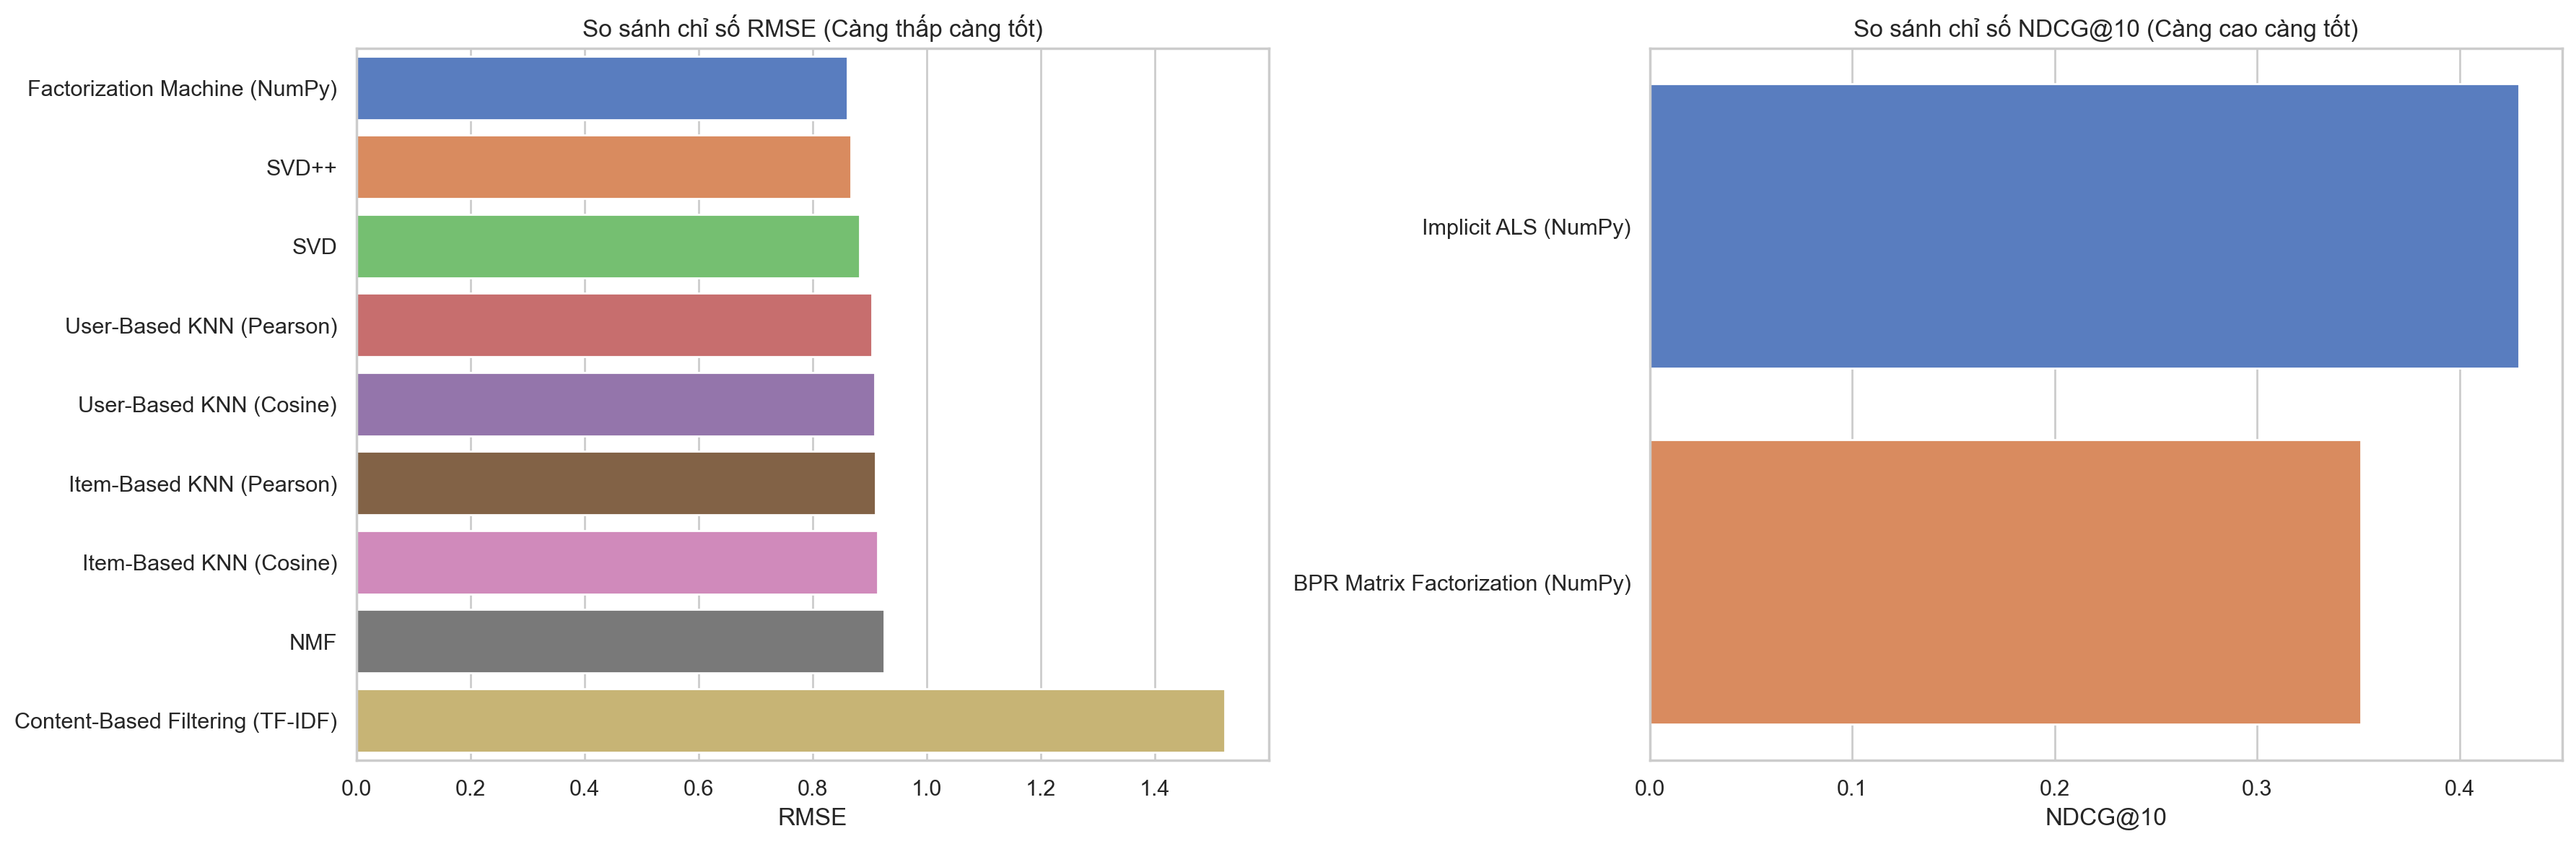

In [12]:
# Chuyển bảng kết quả sang DataFrame
df_explicit = pd.DataFrame(explicit_results).sort_values(by="RMSE")
df_implicit = pd.DataFrame(implicit_results).sort_values(by="NDCG@10", ascending=False)

print("=== KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH RATING DỰ ĐOÁN (EXPLICIT) ===")
display(df_explicit)

print("\n=== KẾT QUẢ ĐÁNH GIÁ CÁC MÔ HÌNH XẾP HẠNG TOP-K LOO (IMPLICIT) ===")
display(df_implicit)

# Trực quan hóa sai số RMSE (Càng thấp càng tốt) và NDCG@10 (Càng cao càng tốt)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=df_explicit, x="RMSE", y="Model", ax=axes[0], hue="Model", legend=False)
axes[0].set_title("So sánh chỉ số RMSE (Càng thấp càng tốt)")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

sns.barplot(data=df_implicit, x="NDCG@10", y="Model", ax=axes[1], hue="Model", legend=False)
axes[1].set_title("So sánh chỉ số NDCG@10 (Càng cao càng tốt)")
axes[1].set_xlabel("NDCG@10")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Phần 9: Phân tích Kết quả Thực nghiệm và Ứng dụng Thực tế

Dựa trên bảng so sánh thực nghiệm phía trên (thực hiện trên tập dữ liệu MovieLens 1M, giao thức Leave-One-Out), chúng ta rút ra các nhận xét quan trọng dưới đây.

> **Tóm tắt kết quả tốt nhất**: FM (Factorization Machine) dẫn đầu nhóm Explicit với **RMSE=0.861**, còn Implicit ALS dẫn đầu nhóm Implicit với **HR@10=0.680, NDCG@10=0.429 và Coverage=31.2%**.

---

### 9.1 Phân tích chi tiết Hiệu năng các Mô hình:

1.  **Nhóm Matrix Factorization (SVD, SVD++, NMF):**
    *   **SVD++ (RMSE=0.868) nhỉnh hơn SVD (RMSE=0.883)** nhờ khai thác thêm implicit feedback – tập hợp tất cả phim mà user đã tương tác (dù chưa chấm điểm). Khoảng cách ~0.015 RMSE tuy nhỏ nhưng có ý nghĩa khi hệ thống đặt mục tiêu cá nhân hóa sâu sắc.
    *   **NMF (RMSE=0.926)** là kém nhất trong nhóm MF vì ràng buộc non-negativity làm giảm tự do biểu diễn vector ẩn. Bù lại, các nhân tố ẩn có thể diễn giải được về mặt ngữ nghĩa (ví dụ: nhân tố phản ánh thể loại phim), điều mà SVD không có.
    *   **Kết luận thực chiến**: SVD là lựa chọn an toàn nhất về tỷ lệ chi phí-hiệu quả. Nếu cần cải thiện vài điểm RMSE, SVD++ đáng đánh đổi thời gian huấn luyện lâu hơn ~2x.

2.  **Nhóm Collaborative Filtering Lân cận (User-KNN, Item-KNN):**
    *   **RMSE nằm trong khoảng 0.904–0.914**, kém hơn nhóm MF khoảng 2–3%. Item-based KNN (Pearson) đạt RMSE=0.911, User-based KNN (Pearson) đạt 0.904 – khoảng cách không đáng kể giữa hai biến thể.
    *   **Hạn chế về bộ nhớ và khả năng mở rộng**: KNN cần lưu toàn bộ ma trận tương đồng $O(N^2)$ hoặc $O(M^2)$. Với MovieLens 1M (6040 users, 3952 movies), điều này có thể quản lý được, nhưng ở quy mô 10M users sẽ không khả thi.
    *   **Kết luận thực chiến**: KNN phù hợp làm baseline hoặc cung cấp gợi ý giải thích được ("vì bạn đã xem..."), nhưng không nên là mô hình chính trong hệ thống sản xuất quy mô lớn.

3.  **Content-Based Filtering:**
    *   **RMSE=1.524, MAE=1.254** – kết quả yếu nhất trong tất cả các mô hình, cách biệt rất lớn so với nhóm MF (~0.66 RMSE points). Nguyên nhân: đặc trưng `genres` quá thô (chỉ ~18 thể loại), không đủ để phân biệt 3952 bộ phim một cách tinh tế.
    *   **Đừng loại bỏ hoàn toàn**: Content-Based là giải pháp duy nhất cho bài toán *item cold start* – phim mới ra chưa có rating. Trong sản xuất, Content-Based thường được ghép với CF trong kiến trúc hybrid (ví dụ: khởi tạo vector phim mới bằng embedding genre trước khi CF lấy lại quyền kiểm soát).
    *   **Cải thiện tiềm năng**: Thay `genres` đơn thuần bằng TF-IDF trên mô tả phim hoặc sentence embedding (BERT) sẽ cải thiện đáng kể RMSE xuống mức cạnh tranh hơn với SVD.

4.  **Factorization Machines (FM) – Kết quả Tốt nhất Explicit:**
    *   **FM đạt RMSE=0.861, MAE=0.656** – tốt nhất trong toàn bộ nhóm explicit, nhỉnh hơn cả SVD++ (0.868). Đáng chú ý là FM hội tụ sau đúng 10 epochs SGD, từ RMSE=0.922 (epoch 1) xuống 0.861 (epoch 10), cho thấy tốc độ học ổn định.
    *   **Lý do thành công**: FM học được tương tác bậc 2 giữa user ID, item ID và `genres` thể loại phim trong không gian ẩn $k$ chiều. Nhờ rút gọn $O(d^2)$ xuống $O(k \cdot d)$, FM xử lý hiệu quả 9,613 đặc trưng thưa thớt.
    *   **Kết luận thực chiến**: FM là mô hình ML truyền thống tốt nhất khi có side information (genres, tags, user demographics). Trong sản xuất, FM là bước đệm lý tưởng trước khi triển khai DL (Wide & Deep hoặc DeepFM).

5.  **BPR & Implicit ALS – Nhóm Implicit Feedback:**
    *   **Implicit ALS (HR@10=0.680, NDCG@10=0.429) vượt trội BPR (HR@10=0.579, NDCG@10=0.352)** trên mọi chỉ số. Khoảng cách HR@10 tới 10.1 percentage points là rất đáng kể trong thực chiến.
    *   **Phân tích Beyond-Accuracy**: Cả hai mô hình có Diversity@10 tương đương (~0.789–0.791), nhưng ALS có **Novelty cao hơn (12.40 vs 11.24)** và **Coverage gấp đôi (31.2% vs 14.7%)**. Coverage thấp của BPR cho thấy mô hình bị thiên vị về các phim phổ biến (popularity bias nặng), gây nguy cơ nghèo hóa danh mục gợi ý về dài hạn.
    *   **Lý do ALS vượt BPR**: ALS tối ưu hóa toàn bộ ma trận tương tác (confidence-weighted) thay vì lấy mẫu cặp ngẫu nhiên như BPR, nhờ đó học biểu diễn user/item toàn cục tốt hơn. Tuy nhiên, ALS đòi hỏi nhiều RAM hơn vì phải lưu confidence matrix $C$.
    *   **Kết luận thực chiến**: Implicit ALS là lựa chọn mặc định vững chắc cho hệ thống implicit feedback. BPR phù hợp hơn khi cần huấn luyện gia tăng (incremental) hoặc tài nguyên bộ nhớ hạn chế.

---

### 9.2 Phân tích Beyond-Accuracy: Diversity, Novelty, Coverage

Chỉ số accuracy (HR@10, NDCG@10, RMSE) chỉ phản ánh khả năng **đoán đúng** của mô hình. Trong môi trường sản xuất, ba chỉ số sau quyết định **trải nghiệm người dùng thực tế**:

| Chỉ số | Implicit ALS | BPR MF |
| :--- | :--- | :--- |
| **Diversity@10** | 0.789 | 0.791 |
| **Novelty@10** | **12.40** | 11.24 |
| **Coverage@10** | **31.2%** | 14.7% |

*   **Coverage** là chỉ số quan trọng nhất với bài toán kinh doanh: ALS phủ 31.2% catalog (~1,233 trong 3,952 phim), trong khi BPR chỉ phủ 14.7% (~581 phim). Hệ thống chỉ gợi ý một tập nhỏ phim phổ biến sẽ gây thiệt hại kinh tế cho nhà cung cấp nội dung dài đuôi (long-tail).
*   **Novelty** của ALS cao hơn (12.40 > 11.24) cho thấy ALS gợi ý phim ít phổ biến hơn nhưng vẫn phù hợp – tín hiệu tốt về khả năng chống popularity bias.
*   **Tradeoff**: Cả hai mô hình có Diversity@10 tương đương (~0.79), nghĩa là các phim trong cùng top-10 không quá giống nhau – tránh được filter bubble.

---

### 9.3 Hướng dẫn Lựa chọn và Ứng dụng các Thuật toán theo Use Case:

| Thuật toán | Sử dụng tối ưu trong trường hợp nào? | Khả năng Giải quyết Cold Start | Độ phức tạp / Scalability | Explainability |
| :--- | :--- | :--- | :--- | :--- |
| **Content-Based** (RMSE=1.52) | Item cold start – phim mới chưa có rating. Kết hợp hybrid để bổ sung cho CF. **Không dùng standalone** do RMSE quá cao. | **Tốt (Item)**: Phim mới vẫn gợi ý được dựa vào genre/mô tả. | **Tốt**: Cosine similarity $O(N \cdot M)$. | **Xuất sắc**: "Vì bạn thích Action/Sci-Fi". |
| **User/Item-Based KNN** (RMSE~0.904–0.914) | Prototype, baseline, hoặc tính năng "người dùng tương tự bạn cũng thích". Không nên dùng trong production quy mô lớn. | **Kém**: User/item mới không có neighbors. | **Kém**: Ma trận tương đồng $O(N^2)$ hay $O(M^2)$. | **Tốt**: Gợi ý dựa trên lịch sử người dùng tương tự. |
| **SVD / SVD++** (RMSE=0.868–0.883) | Nền tảng cá nhân hóa cho user có lịch sử. SVD++ khi muốn thêm ~0.015 điểm RMSE, SVD khi cần train nhanh hơn 2x. | **Rất kém**: Phụ thuộc hoàn toàn vào lịch sử tương tác. | **Trung bình**: Retrain offline batch; inference $O(k)$ rất nhanh. | **Kém**: Latent factors thiếu ngữ nghĩa rõ ràng. |
| **Factorization Machine (FM)** (**RMSE=0.861, tốt nhất**) | Khi có side information (genre, demographics, thời gian). Tốt nhất trong nhóm ML explicit. Bước đệm lý tưởng trước khi triển khai DL. | **Trung bình-Tốt**: Feature embedding giảm cold start qua side info. | **Tốt**: $O(k \cdot d)$ tuyến tính, dễ productionize. | **Trung bình**: Feature importance phân tích được. |
| **BPR MF** (HR@10=0.579, Coverage=14.7%) | Implicit feedback khi RAM hạn chế hoặc cần incremental training. Lưu ý: popularity bias cao (Coverage thấp). | **Kém** | **Tốt**: SGD triplet sampling hội tụ nhanh. | **Kém** |
| **Implicit ALS** (**HR@10=0.680, Coverage=31.2%, tốt nhất**) | **Lựa chọn mặc định cho Implicit Feedback** – vượt trội BPR mọi mặt. Phù hợp Big Data với Spark ALS. Coverage cao nhất (31.2%) giúp giảm popularity bias. | **Kém** | **Rất tốt**: ALS song song hóa tốt; Apache Spark ALS scale đến hàng triệu users. | **Kém** |
